In [10]:
from wjp_judicial_independence.config import PATH_DATA_RAW, PATH_DATA_INTERIM
from wjp_judicial_independence.preprocessing import load_events
from wjp_judicial_independence.classifier import classify_events
from sentence_transformers import SentenceTransformer


# Preprocesamiento
Cargamos los archivos JSON de noticias por país y extraemos eventos individuales. Cada archivo contiene resúmenes de noticias organizados   por pilar del WJP y su impacto (e.g. Very Positive, Negative). Dado que estos resúmenes agrupan múltiples eventos, aplicamos una estrategia de chunking por párrafo (`\n\n`) y filtramos únicamente los párrafos que corresponden a eventos concretos (aquellos que comienzan con `* **`), descartando títulos, conclusiones y texto de relleno.

In [11]:
df = load_events(PATH_DATA_RAW)
df

country,pillar,impact,event
str,str,str,str
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…"
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …"
…,…,…,…
"""ITALY""","""Criminal Justice""","""Negative""","""* **Gender-Based Violence:** T…"
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Mafia Influence:** The ""Ju…"
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Excessive Delays:** The tr…"


# Modelo 1: Clasificación con modelos de embeddings

  Para clasificar si un evento es relevante a **independencia judicial**, utilizamos similitud semántica. Cada evento se codifica como un vector denso $\mathbf{e} \in \mathbb{R}^{N}$ usando el modelo `all-mpnet-base-v2` de sentence-transformers.      
  Definimos tres categorías de referencia relacionadas a independencia judicial basándonos en el documento adjunto de resumen del marco conceptual de independencia judicial de WJP:                                                                             
  - **Cumplimiento de decisiones judiciales:** cobertura sobre si el ejecutivo acata o desafía fallos judiciales políticamente sensibles.
  - **Corrupción judicial:** alegaciones, investigaciones o procesamientos de actores judiciales por soborno o abuso de cargo.
  - **Nombramientos judiciales y confianza pública:** transparencia en nombramientos y percepción ciudadana sobre la imparcialidad del sistema   judicial.

Cada categoría se describe con un texto de referencia que también se codifica como embedding $\mathbf{r} \in \mathbb{R}^{768}$. Luego  calculamos la similitud coseno entre cada evento y cada referencia:
                                                                                                                                             $$\text{score}(e, r) = \frac{\mathbf{e} \cdot \mathbf{r}}{|\mathbf{e}| |\mathbf{r}|}$$                                                      
  Un evento se marca como relevante (`is_judicial_independence = True`) si supera el umbral de similitud en al menos una de las tres categorías. 

**NOTA:** Este modelamiento fue una decisión en desarrollo, el deber ser es probar distintos modelamientos. Por ejemplo, probar si solo teniendo 1 definición completa (en lugar de 3, con cada definición un threshold) da mejores resultados. No se probó por temas de tiempo, pues se dio prioridad también a otro modelamiento más creativo (Modelo 2)

In [12]:
model = SentenceTransformer('all-mpnet-base-v2') # si encontramos algún modelo más apto, simplemente lo cambiamos para que nos de mejores resultados

references = {
    "compliance_with_judicial_decisions": """
        Whether politically sensitive rulings are implemented by the executive 
        or ignored, undermined or defied. News coverage documents executive 
        statements, policy reversals, or civil society responses to non-compliance 
        with court rulings.
    """,
    "judicial_corruption_scandals": """
        Allegations, investigations or prosecutions of judicial actors for bribery, 
        influence trading or abuse of office. Scandals involving judges, frequency 
        and framing of corruption cases and their institutional consequences.
    """,
    "judicial_appointments_and_public_trust": """
        Transparency and contestation around judicial appointments, and public 
        sentiment about judicial fairness and independence. Naming of judges, 
        political salience of appointments, public confidence and trust in courts,
        opinion pieces and editorial framing of judicial impartiality.
    """
}

thresholds = {
    "compliance_with_judicial_decisions": 0.4,
    "judicial_corruption_scandals": 0.4,
    "judicial_appointments_and_public_trust": 0.4
}

df = classify_events(df, model, references, thresholds)
df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


country,pillar,impact,event,embedding,score_compliance_with_judicial_decisions,score_judicial_corruption_scandals,score_judicial_appointments_and_public_trust,is_judicial_independence
str,str,str,str,"array[f32, 768]",f32,f32,f32,bool
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Challenging Unlawful Actio…","[0.055642, 0.030804, … 0.019532]",0.502467,0.640567,0.535574,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Protecting Citizens' Right…","[0.031283, 0.048275, … 0.021095]",0.428725,0.409757,0.471078,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Resisting Political Interf…","[0.043142, 0.027225, … 0.021994]",0.575841,0.648641,0.655584,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Combating Corruption and F…","[-0.020327, 0.069766, … 0.025625]",0.375987,0.548091,0.33353,true
"""POLAND""","""Constraints on Government Powe…","""Very Positive""","""* **Ensuring Transparency and …","[0.011043, 0.065096, … 0.000256]",0.410103,0.424873,0.397865,true
…,…,…,…,…,…,…,…,…
"""ITALY""","""Criminal Justice""","""Negative""","""* **Gender-Based Violence:** T…","[0.017926, 0.113002, … 0.03053]",0.332417,0.389345,0.269603,false
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Mafia Influence:** The ""Ju…","[-0.009093, 0.074971, … 0.029531]",0.399422,0.554401,0.377654,true
"""ITALY""","""Criminal Justice""","""Very Negative""","""* **Excessive Delays:** The tr…","[0.023783, 0.086886, … 0.018032]",0.393736,0.47427,0.383597,true


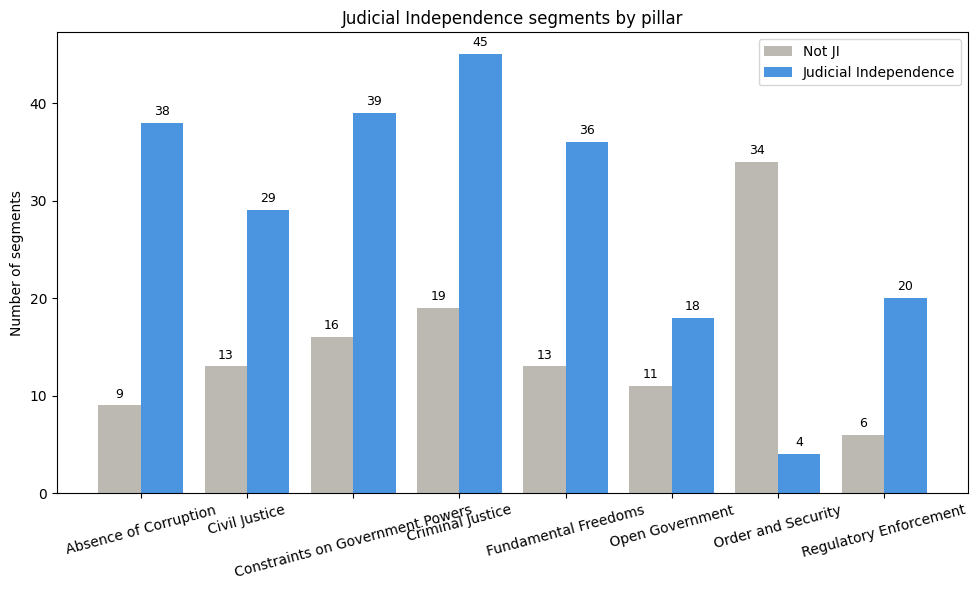

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
df = df.to_pandas()
# Contar por pillar e is_judicial_independence
counts = df.groupby(["pillar", "is_judicial_independence"]).size().unstack(fill_value=0)
counts.columns = ["Not JI", "Judicial Independence"]

# Ordenar por pillar
counts = counts.sort_index()

x = np.arange(len(counts))
width = 0.4

bars1 = ax.bar(x - width/2, counts["Not JI"], width, 
               label="Not JI", color="#B4B2A9", alpha=0.9)
bars2 = ax.bar(x + width/2, counts["Judicial Independence"], width, 
               label="Judicial Independence", color="#378ADD", alpha=0.9)

# Etiquetas de valor encima de cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=15)
ax.set_ylabel("Number of segments")
ax.set_title("Judicial Independence segments by pillar")
ax.legend()

plt.tight_layout()
plt.show()

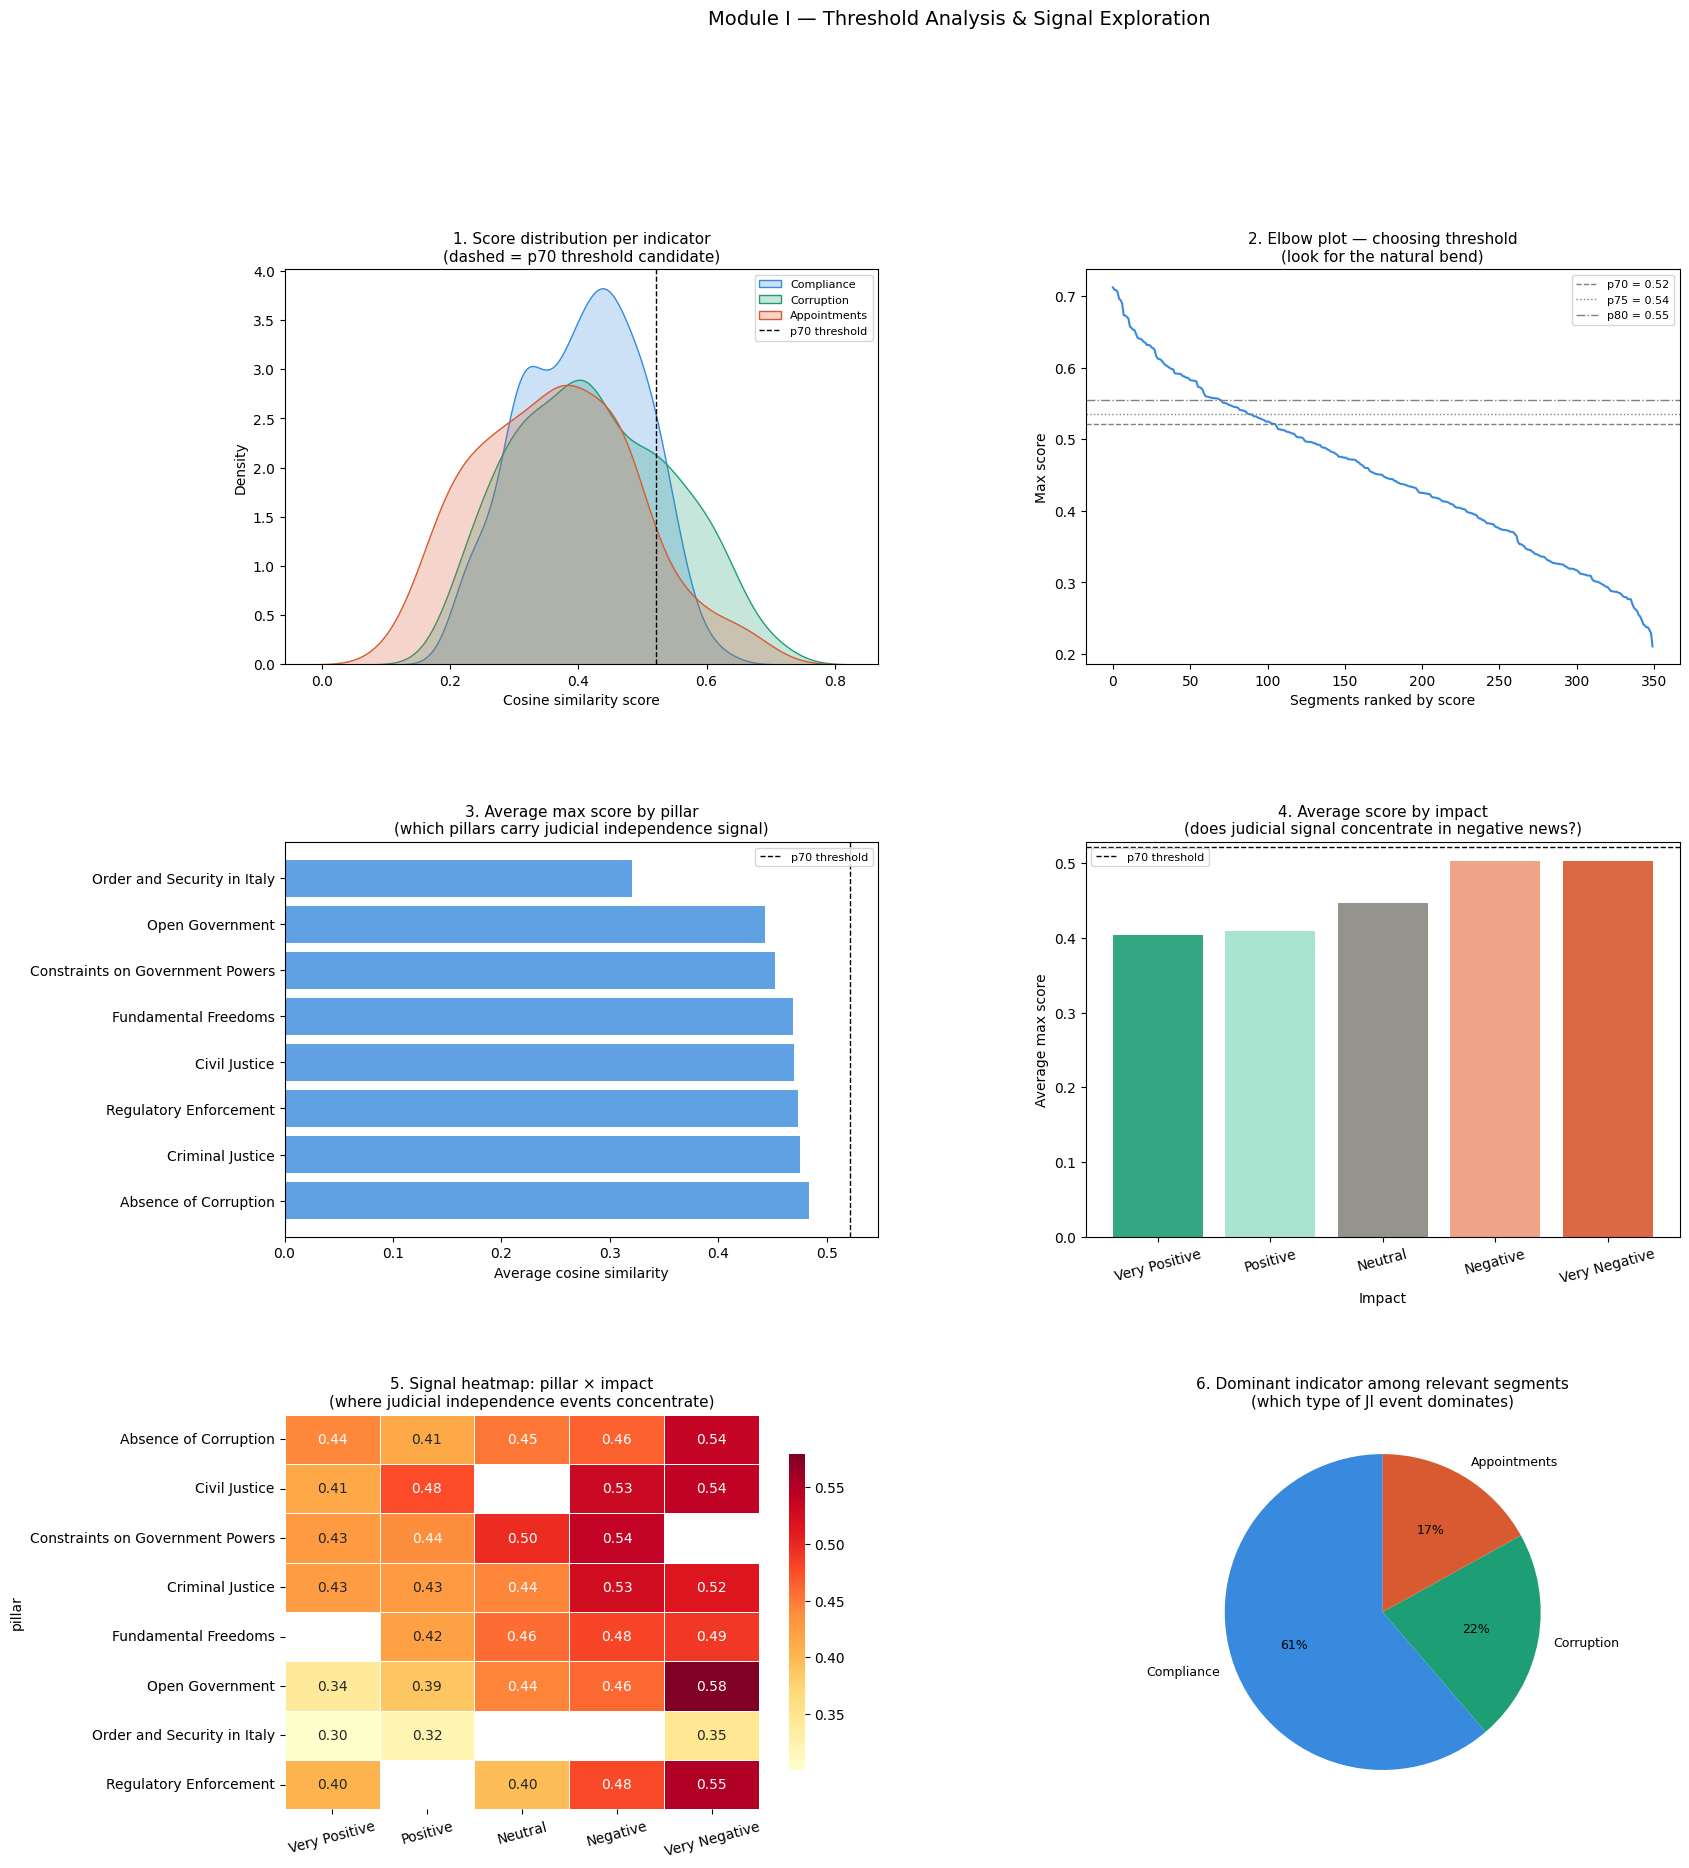

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Setup ─────────────────────────────────────────────────────────────────────
SCORE_COLS = [
    "score_compliance_with_judicial_decisions",
    "score_judicial_corruption_scandals",
    "score_judicial_appointments_and_public_trust"
]
SCORE_LABELS = ["Compliance", "Corruption", "Appointments"]
IMPACT_ORDER = ["Very Positive", "Positive", "Neutral", "Negative", "Very Negative"]
IMPACT_COLORS = {
    "Very Positive": "#1D9E75",
    "Positive":      "#9FE1CB",
    "Neutral":       "#888780",
    "Negative":      "#F0997B",
    "Very Negative": "#D85A30"
}
df = df.to_pandas()
df["max_score"] = df[SCORE_COLS].max(axis=1)
df["top_indicator"] = df[SCORE_COLS].idxmax(axis=1).str.replace("score_", "")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 20))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. KDE por indicador — para ver separación de distribuciones ──────────────
# Útil para elegir threshold: busca el valle entre la masa de ruido y la señal
ax1 = fig.add_subplot(gs[0, 0])
for col, label, color in zip(SCORE_COLS, SCORE_LABELS, ["#378ADD", "#1D9E75", "#D85A30"]):
    sns.kdeplot(df[col], ax=ax1, label=label, fill=True, alpha=0.25, color=color)
ax1.axvline(np.percentile(df["max_score"], 70), color="black", 
            linestyle="--", linewidth=1, label="p70 threshold")
ax1.set_title("1. Score distribution per indicator\n(dashed = p70 threshold candidate)", fontsize=11)
ax1.set_xlabel("Cosine similarity score")
ax1.legend(fontsize=8)

# ── 2. Elbow plot — para calibrar threshold visualmente ───────────────────────
# Ordena los max_scores y grafica: donde la curva se aplana = threshold natural
ax2 = fig.add_subplot(gs[0, 1])
sorted_scores = np.sort(df["max_score"].values)[::-1]
ax2.plot(sorted_scores, color="#378ADD", linewidth=1.5)
for p, ls in [(70, "--"), (75, ":"), (80, "-.")]:
    val = np.percentile(df["max_score"], p)
    ax2.axhline(val, linestyle=ls, color="gray", linewidth=1, label=f"p{p} = {val:.2f}")
ax2.set_title("2. Elbow plot — choosing threshold\n(look for the natural bend)", fontsize=11)
ax2.set_xlabel("Segments ranked by score")
ax2.set_ylabel("Max score")
ax2.legend(fontsize=8)

# ── 3. Score por pillar — ¿qué pillars tienen más señal judicial? ─────────────
ax3 = fig.add_subplot(gs[1, 0])
pillar_scores = df.groupby("pillar")["max_score"].mean().sort_values(ascending=False)
bars = ax3.barh(pillar_scores.index, pillar_scores.values, color="#378ADD", alpha=0.8)
ax3.axvline(np.percentile(df["max_score"], 70), color="black", 
            linestyle="--", linewidth=1, label="p70 threshold")
ax3.set_title("3. Average max score by pillar\n(which pillars carry judicial independence signal)", fontsize=11)
ax3.set_xlabel("Average cosine similarity")
ax3.legend(fontsize=8)

# ── 4. Score por impact — ¿el modelo captura más señal en noticias negativas? ──
ax4 = fig.add_subplot(gs[1, 1])
df["impact"] = pd.Categorical(df["impact"], categories=IMPACT_ORDER, ordered=True)
impact_scores = df.groupby("impact", observed=True)["max_score"].mean()
colors_bar = [IMPACT_COLORS[i] for i in impact_scores.index]
ax4.bar(impact_scores.index, impact_scores.values, color=colors_bar, alpha=0.9)
ax4.axhline(np.percentile(df["max_score"], 70), color="black", 
            linestyle="--", linewidth=1, label="p70 threshold")
ax4.set_title("4. Average score by impact\n(does judicial signal concentrate in negative news?)", fontsize=11)
ax4.set_xlabel("Impact")
ax4.set_ylabel("Average max score")
ax4.tick_params(axis="x", rotation=15)
ax4.legend(fontsize=8)

# ── 5. Heatmap: pillar × impact — dónde está la señal ────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
heatmap_data = df.groupby(["pillar", "impact"], observed=True)["max_score"].mean().unstack()
heatmap_data = heatmap_data.reindex(columns=IMPACT_ORDER)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", 
            ax=ax5, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax5.set_title("5. Signal heatmap: pillar × impact\n(where judicial independence events concentrate)", fontsize=11)
ax5.set_xlabel("")
ax5.tick_params(axis="x", rotation=15)

# ── 6. Distribución de top_indicator entre eventos relevantes ────────────────
ax6 = fig.add_subplot(gs[2, 1])
relevant = df[df["is_judicial_independence"] == True]
indicator_counts = relevant["top_indicator"].value_counts()
wedge_colors = ["#378ADD", "#1D9E75", "#D85A30"]
ax6.pie(indicator_counts.values, labels=SCORE_LABELS, colors=wedge_colors,
        autopct="%1.0f%%", startangle=90, textprops={"fontsize": 9})
ax6.set_title("6. Dominant indicator among relevant segments\n(which type of JI event dominates)", fontsize=11)

plt.suptitle("Module I — Threshold Analysis & Signal Exploration", fontsize=14, y=1.01)
plt.show()

# Modelo 2: Clasificación con modelos de embeddings + LLMs + Aprendizaje Supervisado

En lugar de hacerlo directo con el truco de crear embeddings de referencias, le pedimos a un modelo de lenguaje grande, como gpt, opus, etc. que de un score de 0 a 1 para is judicial independence, que nos de un threshold óptimo de acuerdo a su score. y utilizamos esto como base para hacer clasificación con aprendizaje supervisado.